### Question 2a

In [2]:
import pandas as pd

# URL for the CSV file
url = 'https://github.com/nytimes/covid-19-data/raw/master/us-states.csv'

# Load the CSV directly from the URL
data = pd.read_csv(url)

# Convert the 'date' column to datetime format for easier manipulation
data['date'] = pd.to_datetime(data['date'])

# Sort the data by state and date
data = data.sort_values(['state', 'date'])

# Calculate new daily cases by subtracting the previous day's cumulative cases within each state
data['new_cases'] = data.groupby('state')['cases'].diff().fillna(0)

### Question 2b

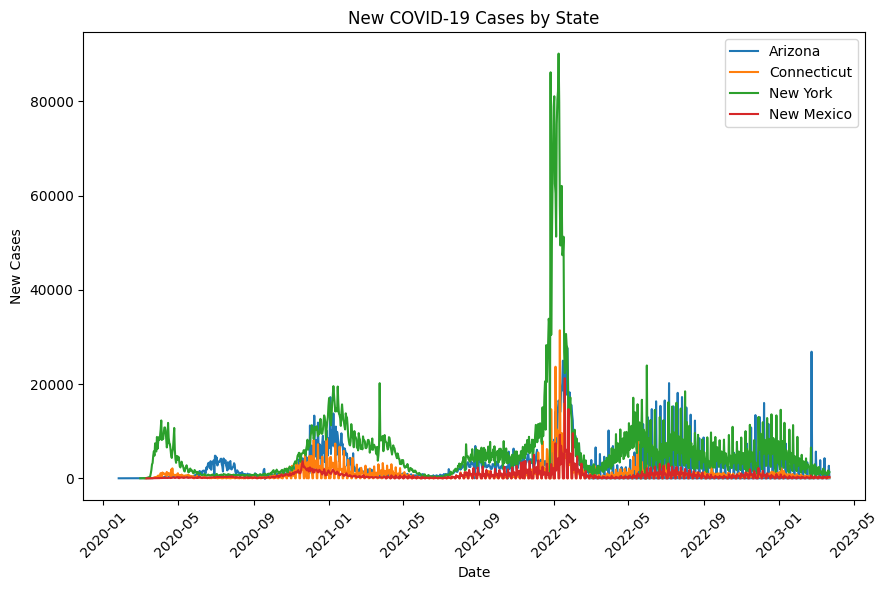

In [24]:
import matplotlib.pyplot as plt

def plot_new_cases(states):
  
    plt.figure(figsize=(9, 6))
    
    # Plot the new cases for each state
    for state in states:
        state_data = data[data['state'] == state]
        plt.plot(state_data['date'], state_data['new_cases'], label=state)
    
    # Labeling the plot
    plt.xlabel('Date')
    plt.ylabel('New Cases')
    plt.title('New COVID-19 Cases by State')
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    
    # Show the plot
    plt.show()

# Example usage:
plot_new_cases(['Arizona','Connecticut','New York','New Mexico'])


### Question 2c

In [30]:
def find_peak_case_date(state):
    
    # Filter data for the specified state
    state_data = data[data['state'] == state]
    
    # Find the date with the highest number of new cases
    peak_day = state_data.loc[state_data['new_cases'].idxmax()]
    
    return peak_day['date'], int(peak_day['new_cases'])

# Example usage:
find_peak_case_date('Illinois')

(Timestamp('2022-01-18 00:00:00'), 93423)

### Question 2d

In [32]:
def compare_peak_cases(state1, state2):
    
    # Get the peak dates for both states
    peak_date1, _ = find_peak_case_date(state1)
    peak_date2, _ = find_peak_case_date(state2)
    
    # Compare the peak dates and calculate the difference in days
    if peak_date1 < peak_date2:
        first_peak_state = state1
        days_between = (peak_date2 - peak_date1).days
    else:
        first_peak_state = state2
        days_between = (peak_date1 - peak_date2).days
    
    return f"{first_peak_state} peaked first, with a difference of {days_between} days between peaks."

# Example usage:
compare_peak_cases('Missouri', 'Alabama')

'Missouri peaked first, with a difference of 327 days between peaks.'

### Question 2e

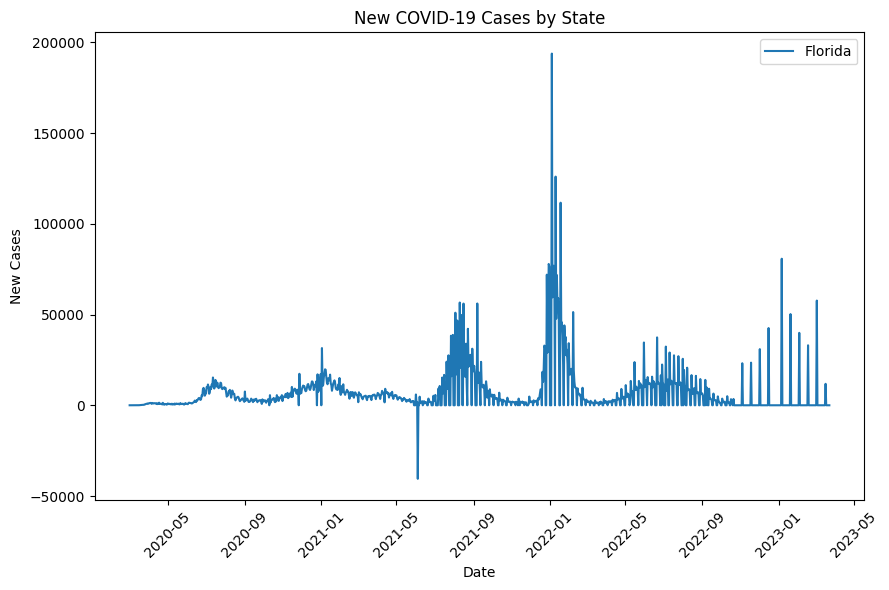

In [34]:
# Plot the new cases in Florida
plot_new_cases(['Florida'])
